In [1]:
import cv2
import numpy as np
import torch 

import tensorflow as tf
import pandas as pd

import pathlib 
import os
import string
from PIL import Image
from keras import backend as K
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt
from PIL import Image
import random, os
import numpy as np
import shap

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#train and test data directory
train_dir = "Dataset/train"
test_dir = "Dataset/test"
val_dir = "Dataset/valid"
num_train_files = sum([len(files) for r, d, files in os.walk(train_dir)])
num_test_files = sum([len(files) for r, d, files in os.walk(test_dir)])
num_val_files = sum([len(files) for r, d, files in os.walk(val_dir)])

print(f"Number of files in the train directory: {num_train_files}")
print(f"Number of files in the test directory: {num_test_files}")
print(f"Number of files in the test directory: {num_val_files}")

Number of files in the train directory: 10000
Number of files in the test directory: 1705
Number of files in the test directory: 0


In [3]:
class ImageFolderEX(torchvision.datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            sample = self.loader(path)
        except:
            return None
        if self.transform is not None:
            sample = self.transform(sample)
        if self.target_transform is not None:
            target = self.target_transform(target)
        return sample, target
transform = transforms.Compose([transforms.Resize((128,128)),
                                transforms.ToTensor()])

In [4]:
#load the train and test data
dataset = ImageFolderEX(train_dir, transform = transform)
test_ds = ImageFolderEX(test_dir, transform = transform)

print('dataset samples:', len(dataset))
print('test samples:', len(test_ds))
print("Classes are:", dataset.classes)

img, label = dataset[0]
print(f'Example: first sample size: {img.shape}, and label: {label}')

dataset samples: 10000
test samples: 1703
Classes are: ['colon_aca', 'colon_n']
Example: first sample size: torch.Size([3, 128, 128]), and label: 0


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
ge = ImageDataGenerator(rescale = 1/255,
                        rotation_range=0.2,
                        width_shift_range=0.05,
                        height_shift_range=0.05,
                        fill_mode = 'constant',
                        validation_split = 0.2,
                        horizontal_flip = True,
                        vertical_flip = True,
                        zoom_range = 0.2
                       )

In [6]:
datasetfolder = 'Dataset/train'
dataflowtraining = ge.flow_from_directory(directory = datasetfolder,
                                 target_size = (128, 128),
                                 color_mode = 'rgb',
                                 batch_size = 64,
                                 shuffle = True,
                                 subset = 'training')
datasetfolder1='Dataset/train'
dataflowvalidation = ge.flow_from_directory(directory = datasetfolder1,
                                           target_size = (128, 128),
                                           color_mode = 'rgb',
                                           batch_size = 64,
                                           shuffle = True,
                                           subset = 'validation')

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [7]:
batch = next(dataflowvalidation)
images, labels = batch
print(np.min(images), np.max(images))

0.0 1.0


C:\Users\nishu\AppData\Local\Temp\ipykernel_19772\1089697816.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


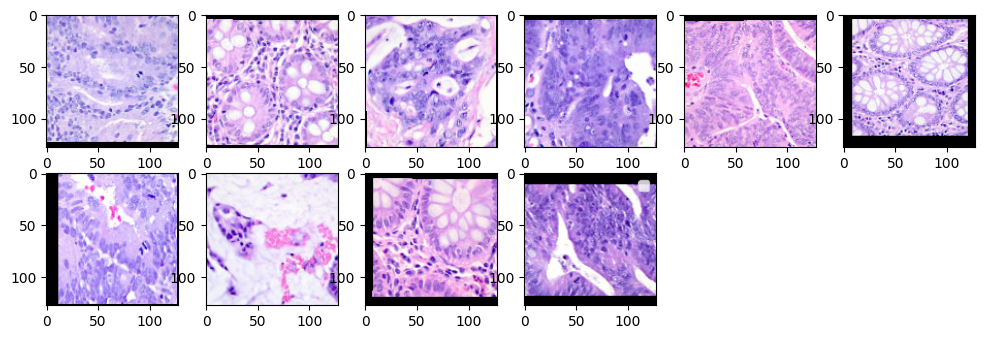

In [8]:
plt.figure(figsize = (12, 12))
for i in range(10):
    plt.subplot(6, 6, (i + 1))
    plt.imshow(images[i])

plt.legend()

In [14]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, Model
import tensorflow as tf

# Define Squeeze-and-Excitation Layer
@tf.keras.utils.register_keras_serializable()
class SqueezeExciteLayer(layers.Layer):
    def __init__(self, ratio=16, **kwargs):
        super(SqueezeExciteLayer, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        # Squeeze operation (Global Average Pooling)
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        
        # Excite operation (Fully connected layers)
        self.dense1 = layers.Dense(input_shape[-1] // self.ratio, activation='relu', use_bias=False)
        self.dense2 = layers.Dense(input_shape[-1], activation='sigmoid', use_bias=False)
        super(SqueezeExciteLayer, self).build(input_shape)

    def call(self, inputs, training=False):
        # Apply squeeze and excitation
        x = self.global_avg_pool(inputs)  # Squeeze
        x = self.dense1(x)  # Excite (1st dense layer)
        x = self.dense2(x)  # Excite (2nd dense layer)
        x = layers.Reshape((1, 1, inputs.shape[-1]))(x)  # Reshape to the same shape as input
        return inputs * x  # Scale the input by the excitation

# Load base DenseNet121 model without top layers
basemodel = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3), pooling=None)

# Apply spatial attention after the base model
se_output = SqueezeExciteLayer()(basemodel.output)

# Flatten and add other layers
x = tf.keras.layers.Flatten()(se_output)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.BatchNormalization()(x)
output = tf.keras.layers.Dense(2, activation='softmax')(x)

# Define the final model
m = Model(inputs=basemodel.input, outputs=output)

# Compile the model
m.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

In [15]:
print(m.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_6              │ (None, 134, 134, 3)       │               0 │ input_layer_3[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,408 │ zero_padding2d_6[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_7              │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 32, 32, 64)        │               0 │ zero_padding2d_7[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 32, 32, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 32, 32, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,496,370 (28.60 MB)

 Trainable params: 7,379,922 (28.15 MB)

 Non-trainable params: 116,448 (454.88 KB)

None


In [16]:
hist = m.fit(dataflowtraining, epochs = 30, batch_size = 64,
             validation_data = dataflowvalidation,
             callbacks = [
                tf.keras.callbacks.EarlyStopping(patience = 4, monitor = 'val_loss', mode = 'min',
                                                restore_best_weights = True),
                tf.keras.callbacks.ReduceLROnPlateau(patience = 4, monitor = 'val_loss',
                                                          mode = 'min', factor = 0.1)
            ])

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1238s 9s/step - accuracy: 0.8705 - loss: 0.4282 - precision: 0.8705 - recall: 0.8705 - val_accuracy: 0.9955 - val_loss: 0.1703 - val_precision: 0.9955 - val_recall: 0.9955 - learning_rate: 1.0000e-04
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 886s 7s/step - accuracy: 0.9920 - loss: 0.1999 - precision: 0.9920 - recall: 0.9920 - val_accuracy: 0.9990 - val_loss: 0.1347 - val_precision: 0.9990 - val_recall: 0.9990 - learning_rate: 1.0000e-04
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 849s 7s/step - accuracy: 0.9942 - loss: 0.1728 - precision: 0.9942 - recall: 0.9942 - val_accuracy: 1.0000 - val_loss: 0.1143 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 851s 7s/step - accuracy: 0.9952 - loss: 0.1557 - precision: 0.9952 - recall: 0.9952 - val_accuracy: 1.0000 - val_loss: 0.0909 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 885

In [17]:
m.evaluate(dataflowtraining)

125/125 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 1.0000 - loss: 0.0057 - precision: 1.0000 - recall: 1.0000


[0.005637499038130045, 1.0, 1.0, 1.0]

In [18]:
m.evaluate(dataflowvalidation)

32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 1.0000 - loss: 0.0057 - precision: 1.0000 - recall: 1.0000


[0.005643934477120638, 1.0, 1.0, 1.0]

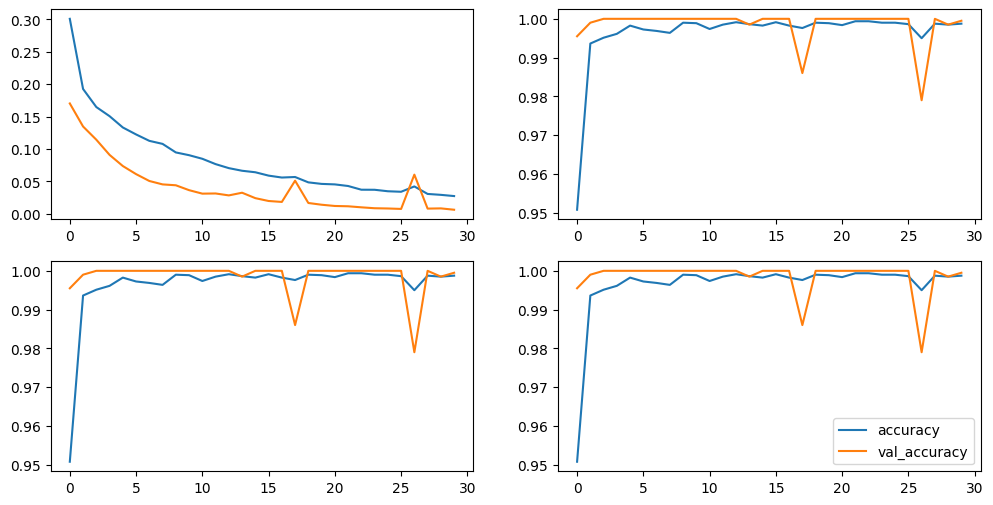

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))
metrics = ['loss', 'precision', 'recall', 'accuracy']
for i in range(4):
    plt.subplot(2, 2, (i + 1))
    plt.plot(hist.history[metrics[i]], label = metrics[i])
    plt.plot(hist.history['val_{}'.format(metrics[i])], label = 'val_{}'.format(metrics[i]))
plt.legend()

In [20]:
m.save('densenet121se.keras')

In [21]:
m = tf.keras.models.load_model('densenet121se.keras')

In [31]:
def gradCam(image, true_label, layer_conv_name):
    # Define the model for Grad-CAM
    model_grad = tf.keras.models.Model(inputs=m.input, 
                                       outputs=[m.get_layer(layer_conv_name).output, m.output])
    
    with tf.GradientTape() as tape:
        conv_output, predictions = model_grad(image)
        tape.watch(conv_output)
        loss = tf.keras.losses.binary_crossentropy(true_label, predictions)
    
    # Compute gradients and process them
    grad = tape.gradient(loss, conv_output)
    grad = tf.reduce_mean(tf.abs(grad), axis=(0, 1, 2))  # Use tf.reduce_mean
    
    # Process the conv_output
    conv_output = np.squeeze(conv_output.numpy())
    for i in range(conv_output.shape[-1]):
        conv_output[:, :, i] *= grad[i]
    
    # Generate heatmap and resize it
    heatmap = tf.reduce_mean(conv_output, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)  # Normalize between 0 and 1
    heatmap = cv2.resize(heatmap.numpy(), (128, 128))
    
    return np.squeeze(heatmap), np.squeeze(image)

In [32]:
def getHeatMap(images, labels):
    heatmaps = []
    for index in range(12):  # Modify range if needed
        heatmap, image = gradCam(images[index: index + 1], 
                                 labels[index: index + 1], 
                                 'relu')
        heatmaps.append(heatmap)
    return np.array(heatmaps)

In [33]:
heatmaps = getHeatMap(images, labels)
print(heatmaps.shape)

(12, 128, 128)


In [34]:
def grad_cam_plus_plus(image, true_label, conv_layer):
    gradModel = tf.keras.models.Model(inputs=m.input, 
                                      outputs=[m.get_layer(conv_layer).output, m.output])
    
    with tf.GradientTape() as tape:
        conv_output, predict = gradModel(image)
        tape.watch(conv_output)
        # Corrected to ensure scalar indexing
        score = predict[:, np.argmax(predict, axis=-1).item()]
    
    # Compute the gradients
    grads = tape.gradient(score, conv_output)
    grads = tf.reduce_mean(tf.abs(grads), axis=[0, 1, 2])  # Use tf.reduce_mean
    
    # Grad-CAM++ specific calculations
    score_exp = tf.exp(score)
    first = score_exp * grads
    second = score_exp * grads * grads
    third = score_exp * grads * grads * grads
    
    conv_output = conv_output[0]  # Remove batch dimension
    
    # Sum along spatial dimensions for Grad-CAM++ weighting
    x = tf.reduce_sum(conv_output, axis=[0, 1])
    grads = second / (2 * second + third * x + tf.keras.backend.epsilon())  # Prevent division by zero
    
    # Apply Grad-CAM++ weighting
    conv_output = conv_output.numpy()
    for i in range(conv_output.shape[-1]):
        conv_output[:, :, i] *= grads[i]
    
    # Generate heatmap
    heatmap = tf.reduce_mean(conv_output, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)  # Normalize to 0-1
    heatmap = cv2.resize(heatmap.numpy(), (128, 128))  # Resize to 128x128
    
    return heatmap 

In [35]:
def getHeatMap_plus_plus(images, labels, conv_layer='relu'):
    heatmaps = []
    num_images = len(images)  # Dynamically set the number of images to process
    for index in range(num_images):
        heatmap = grad_cam_plus_plus(images[index: index + 1], 
                                     labels[index: index + 1], 
                                     conv_layer)
        heatmaps.append(heatmap)
    return np.array(heatmaps)

In [61]:
GradCamplusheatmaps = getHeatMap_plus_plus(images[:20], labels[:20])
print("Shape of GradCamplusheatmaps:", GradCamplusheatmaps.shape)

Shape of GradCamplusheatmaps: (20, 128, 128)


In [62]:
def draw_compare(images, gradcam_heatmaps, 
                 gradcamplus_heatmaps, labels):
  plt.figure(figsize = (12, 40))
  index = 0
  n = 0
  for i in range(40):
    plt.subplot(20, 6, (i + 1))
    if index == 0:
      plt.imshow(images[n])
      plt.title('Image-class: {}'.format(labels[n]))
      index = 1
    elif index == 1:
      plt.imshow(images[n])
      plt.imshow(gradcam_heatmaps[n], alpha = 0.6, cmap = 'jet')
      plt.title('Grad-Cam')
      index = 2
    elif index == 2:
      plt.imshow(images[n])
      plt.imshow(gradcamplus_heatmaps[n], alpha = 0.6, cmap = 'jet')
      plt.title('Grad-Cam++')
      index = 0
      n = n + 1
  plt.legend()

In [63]:
l = np.argmax(labels, axis = 1)
l.shape

(64,)

IndexError: index 12 is out of bounds for axis 0 with size 12

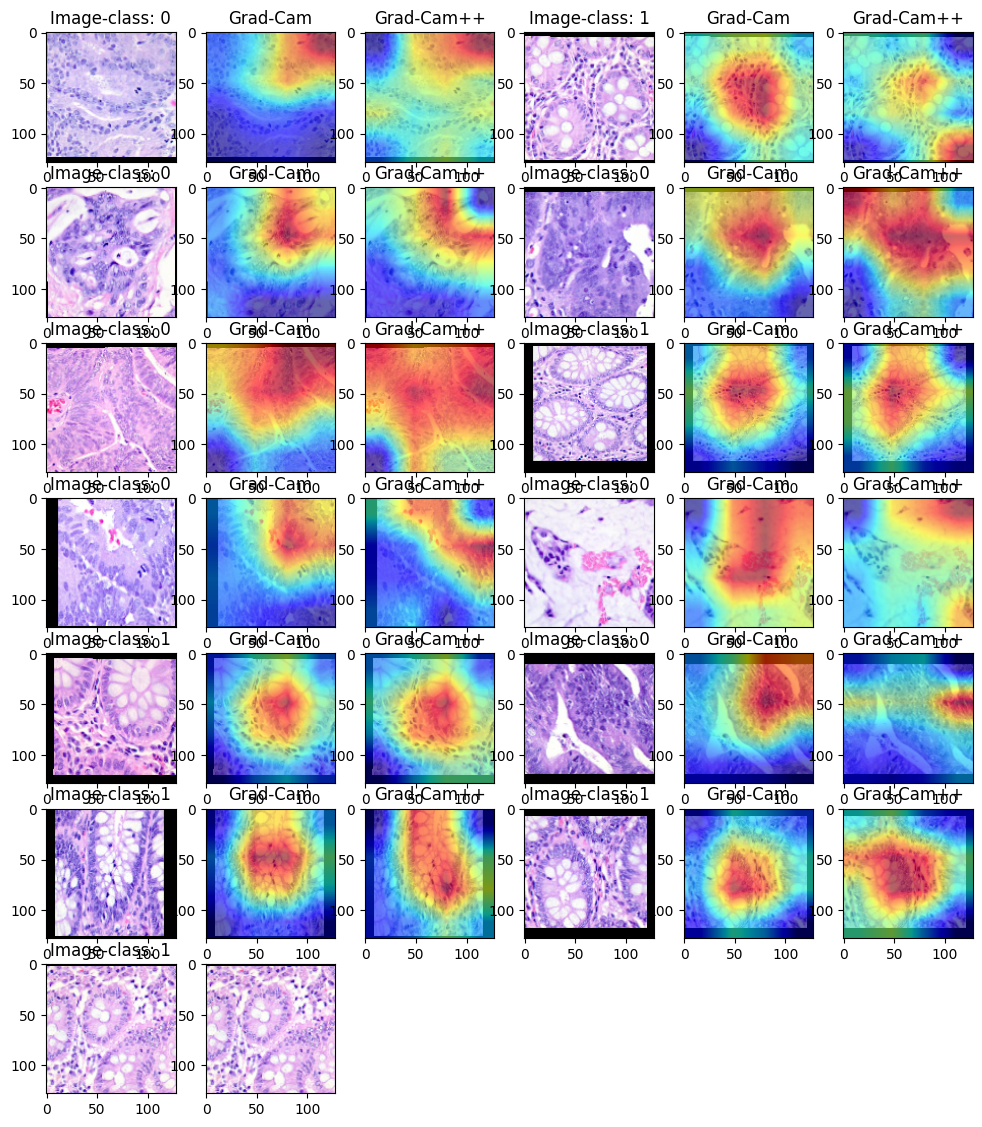

In [64]:
import matplotlib.pyplot as plt
draw_compare(images[:20], heatmaps[:20], 
                 GradCamplusheatmaps[:20], l[:20])

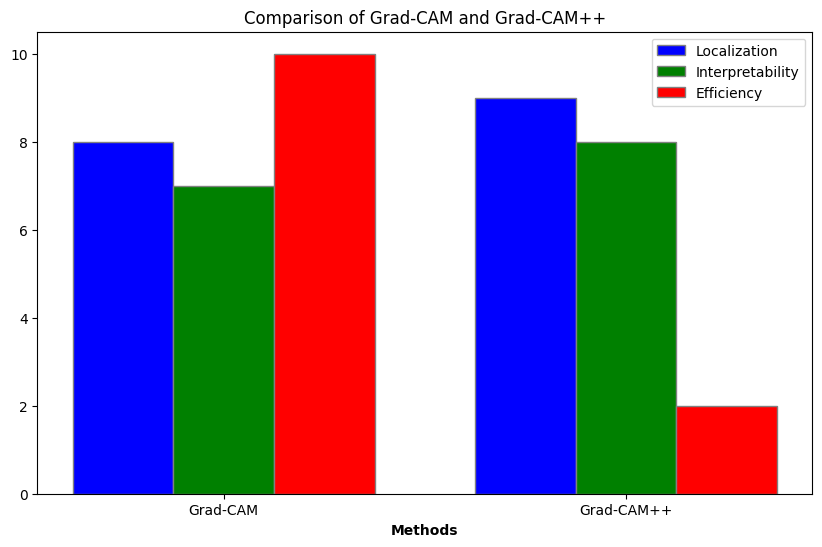

In [71]:
import time
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Measure computational efficiency
def measure_efficiency(images, labels, method):
    start_time = time.time()
    
    if method == 'Grad-CAM':
        heatmaps = getHeatMap(images, labels)
    elif method == 'Grad-CAM++':
        heatmaps = getHeatMap_plus_plus(images, labels)
        
    end_time = time.time()
    time_taken = end_time - start_time
    return time_taken, heatmaps

# Measure efficiency for both Grad-CAM and Grad-CAM++
time_gradcam, heatmaps_gradcam = measure_efficiency(images[:128], labels[:128], 'Grad-CAM')
time_gradcam_plus, heatmaps_gradcam_plus = measure_efficiency(images[:128], labels[:128], 'Grad-CAM++')

# Step 2: Set subjective scores (out of 10) for localization and interpretability
# Assuming you inspect some heatmaps and assign the following scores:
localization_scores = {'Grad-CAM': 8, 'Grad-CAM++': 9}
interpretability_scores = {'Grad-CAM': 7, 'Grad-CAM++': 8}

# Computational Efficiency (inverse time taken, lower time is better)
efficiency_scores = {
    'Grad-CAM': 1 / time_gradcam,
    'Grad-CAM++': 1 / time_gradcam_plus
}

# Normalize efficiency scores for a fair comparison
max_efficiency = max(efficiency_scores.values())
efficiency_scores = {key: (value / max_efficiency) * 10 for key, value in efficiency_scores.items()}

# Step 3: Plot a bar chart for comparison
methods = ['Grad-CAM', 'Grad-CAM++']
localization = [localization_scores[method] for method in methods]
interpretability = [interpretability_scores[method] for method in methods]
efficiency = [efficiency_scores[method] for method in methods]

# Bar width
bar_width = 0.25

# Set position of bar on X axis
r1 = np.arange(len(methods))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Make the plot
plt.figure(figsize=(10,6))
plt.bar(r1, localization, color='b', width=bar_width, edgecolor='grey', label='Localization')
plt.bar(r2, interpretability, color='g', width=bar_width, edgecolor='grey', label='Interpretability')
plt.bar(r3, efficiency, color='r', width=bar_width, edgecolor='grey', label='Efficiency')

# Add xticks on the middle of the group bars
plt.xlabel('Methods', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(methods))], methods)

# Create legend
plt.legend()

# Show the plot
plt.title('Comparison of Grad-CAM and Grad-CAM++')
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


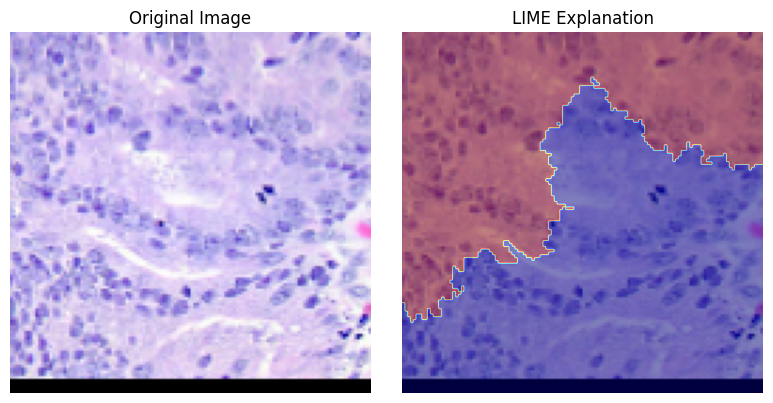

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image

# Define the explain_with_lime function
def explain_with_lime(image, m):
    # Initialize the LIME explainer
    explainer = lime_image.LimeImageExplainer()

    # Define a predict function for LIME that wraps the model
    def predict_fn(images):
        images = np.array(images)  # Ensure the images are a numpy array
        return m.predict(images)  # Use the provided model for prediction

    # Run LIME explanation
    explanation = explainer.explain_instance(
        image[0],  # Use the image directly if it's already a NumPy array
        predict_fn,
        top_labels=2,
        hide_color=1,
        num_samples=10
    )

    # Get explanation for the top predicted label
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )

    # Plot the original image and the LIME mask side by side
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # Original image
    axes[0].imshow(image[0])  # Show the original image
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # LIME-processed image
    axes[1].imshow(temp)
    axes[1].imshow(mask, cmap='jet', alpha=0.5)  # Overlay the mask on the image
    axes[1].set_title("LIME Explanation")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage with an image from your dataset
explain_with_lime(images[:5], m)  # Ensure 'm' is the name of your model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

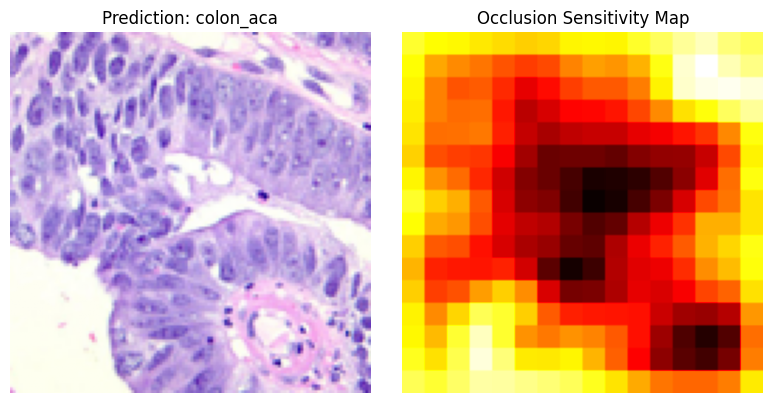

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Preprocessing function
def preprocess_image(image_path):
    # Load the image
    image = Image.open(image_path)
    # Resize to match model's expected input size
    image = image.resize((128, 128))  # Adjust size based on your model
    # Normalize image to [0, 1]
    image_array = np.array(image) / 255.0
    return image_array

# Occlusion sensitivity function
def occlusion_sensitivity(m, image, label, patch_size=16, step_size=8):
    original_prediction = m.predict(image[None, ...])  # Add batch dimension
    original_score = original_prediction[0][label]  # Get score for the predicted class

    height, width, _ = image.shape
    sensitivity_map = np.zeros((height, width))

    # Iterate through patches
    for i in range(0, height - patch_size + 1, step_size):
        for j in range(0, width - patch_size + 1, step_size):
            # Occlude the patch
            occluded_image = np.copy(image)
            occluded_image[i:i+patch_size, j:j+patch_size, :10] = 0
            occluded_prediction = m.predict(occluded_image[None, ...])
            occluded_score = occluded_prediction[0][label]
            # Calculate sensitivity for the patch
            sensitivity_map[i:i+patch_size, j:j+patch_size] += original_score - occluded_score

    return sensitivity_map

# Main function
def classify_and_display(image_path):
    # Preprocess the image
    processed_image = preprocess_image(image_path)
    processed_image_with_batch = processed_image[None, ...]  # Add batch dimension

    # Predict the label
    prediction = m.predict(processed_image_with_batch)
    predicted_class = np.argmax(prediction)
    class_labels = {1: 'colon_n', 0: 'colon_aca'}
    predicted_label = class_labels[predicted_class]

    # Generate occlusion sensitivity map
    sensitivity_map = occlusion_sensitivity(m, processed_image, predicted_class)
    
    # Plot results side by side
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))  # Change to 1x2 grid

    # Display original image
    axes[0].imshow(processed_image)
    axes[0].set_title(f"Prediction: {predicted_label}")
    axes[0].axis('off')

    # Display occlusion sensitivity map
    axes[1].imshow(sensitivity_map, cmap='hot')
    axes[1].set_title("Occlusion Sensitivity Map")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
image_path = 'Dataset/train/colon_aca/colonca1002.jpeg'  # Replace with your image path
classify_and_display(image_path)

In [80]:
import time
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Measure computational efficiency
def measure_efficiency(images, labels, method):
    start_time = time.time()
    
    if method == 'Occlusion-sensitivity':
        heatmaps = occlusion_sensitivity(m, images, label)
    elif method == 'LIME':
        heatmaps =  explain_with_lime(images, m)
        
    end_time = time.time()
    time_taken = end_time - start_time
    return time_taken, heatmaps

# Measure efficiency for both Grad-CAM and Grad-CAM++
time_occlusionsensitivity, heatmaps_occlusionsensitivity = measure_efficiency(images[:128], labels[:128], 'Occlusion-sensitivity')
time_lime, heatmaps_lime = measure_efficiency(images[:128], labels[:128], 'LIME')

# Step 2: Set subjective scores (out of 10) for localization and interpretability
# Assuming you inspect some heatmaps and assign the following scores:
localization_scores = {'Occlusion-sensitivity': 8, 'LIME': 9}
interpretability_scores = {'Occlusion-sensitivity': 7, 'LIME': 8}

# Computational Efficiency (inverse time taken, lower time is better)
efficiency_scores = {
    'Occlusion-sensitivity': 1 / time_occlusionsensitivity,
    'LIME': 1 / time_lime
}

# Normalize efficiency scores for a fair comparison
max_efficiency = max(efficiency_scores.values())
efficiency_scores = {key: (value / max_efficiency) * 10 for key, value in efficiency_scores.items()}

# Step 3: Plot a bar chart for comparison
methods = ['Occlusion-sensitivity', 'LIME']
localization = [localization_scores[method] for method in methods]
interpretability = [interpretability_scores[method] for method in methods]
efficiency = [efficiency_scores[method] for method in methods]

# Bar width
bar_width = 0.25

# Set position of bar on X axis
r1 = np.arange(len(methods))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Make the plot
plt.figure(figsize=(10,6))
plt.bar(r1, localization, color='b', width=bar_width, edgecolor='grey', label='Localization')
plt.bar(r2, interpretability, color='g', width=bar_width, edgecolor='grey', label='Interpretability')
plt.bar(r3, efficiency, color='r', width=bar_width, edgecolor='grey', label='Efficiency')

# Add xticks on the middle of the group bars
plt.xlabel('Methods', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(methods))], methods)

# Create legend
plt.legend()

# Show the plot
plt.title('Comparison of Occlusion Sensitivity and LIME')
plt.show()

ValueError: as_list() is not defined on an unknown TensorShape.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


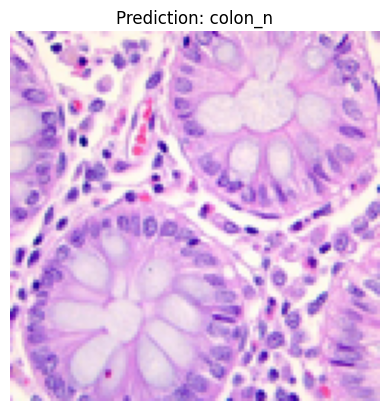

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


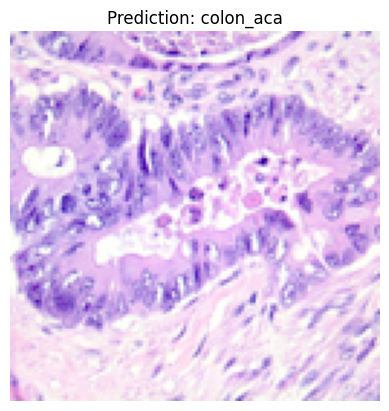

In [67]:
def preprocess_image(image_path):
    # Load the image
    image = Image.open(image_path)
    # Resize and normalize the image
    image = image.resize((128, 128))  # Adjust size if needed
    image_array = np.array(image) / 255.0  # Normalize to [0, 1]
    return image_array

def classify_and_display(image_path):
    # Load and preprocess the image
    processed_image = preprocess_image(image_path)
    processed_image = processed_image[None, ...]  # Add batch dimension

    # Get model prediction
    prediction = m.predict(processed_image)
    
    # Get the predicted class
    predicted_class = np.argmax(prediction)
    
    # Prepare labels
    class_labels = {1: 'colon_n', 0: 'colon_aca'}
    predicted_label = class_labels[predicted_class]
    
    # Display the image with prediction
    plt.imshow(processed_image[0])  # Display the original image
    plt.title(f'Prediction: {predicted_label}')
    plt.axis('off')
    plt.show()

# Example usage
image_path = 'Dataset/train/colon_n/colonn3018.jpeg'  # Replace with your image path
classify_and_display(image_path)

image_path = 'Dataset/train/colon_aca/colonca1000.jpeg'  # Replace with your image path
classify_and_display(image_path)